In [ ]:
!pip -q install lime
!pip -q install captum

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 22.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 24.5 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from torchvision import models
import lime
import lime.lime_tabular
from lime import lime_image
from sklearn.metrics import accuracy_score
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt
import os
from captum.attr import IntegratedGradients, LayerGradCam
import torch.nn.functional as F

# Utilizzo di un Modello di Classificazione Pre-Addestrato

## Dettaglio e analisi dataset MNIST:
- 60.000 immagini training
- 10.000 test
- scala di grigi
- 28×28
- cifre 0-9, nel progetto verranno ridimensionate a 224×224 e
convertite in RGB per DenseNet.

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

trainset = torchvision.datasets.MNIST(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.MNIST(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64,
                                         shuffle=False, num_workers=2)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.01MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.7MB/s]


In [ ]:
# DenseNet-121 pre-addestrata su ImageNet
model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 82.8MB/s]


In [ ]:
num_classes = 10

model.classifier = nn.Linear(model.classifier.in_features, num_classes)

In [ ]:
for param in model.parameters():
    param.requires_grad = False

model.classifier = nn.Linear(model.classifier.in_features, num_classes)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = model.to(device)

cuda


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

In [ ]:
epochs = 5

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, labels in trainloader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{epochs} "
        f"Loss: {running_loss/len(trainloader):.4f}"
    )

print('Finished Training')
torch.save(model.state_dict(), 'DenseNet_MNIST.pt')

Epoch 1/5 Loss: 0.6131
Epoch 2/5 Loss: 0.2939
Epoch 3/5 Loss: 0.2414
Epoch 4/5 Loss: 0.2147
Epoch 5/5 Loss: 0.1988
Finished Training


In [ ]:
model.eval()

test_loss = 0
correct = 0
total = 0

with torch.no_grad():

    for images, labels in testloader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()


test_loss /= len(testloader)
accuracy = 100 * correct / total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {accuracy:.2f}%")

Test Loss: 0.1804
Test Accuracy: 94.97%


L’accuracy del modello, pari circa al 95%, conferma una buona capacità predittiva sul task richiesto. Tuttavia, nel contesto di Explainable AI la bontà del modello non esaurisce la valtazione del progetto: è necessario anche comprendere come il modello arrivi alle sue decisioni. Per questo motivo l’analisi si è concentrata sulle mappe di salienza e sulla lettura delle differenze tra casi corretti ed errati. In altre parole, la prestazione predittiva valida il modello, mentre le tecniche XAI ne chiariscono il funzionamento e i limiti.

# Generazione di Mappe di Salienza
In questo progetto sono state implementate LIME, Integrated Gradients e Grad-CAM. SHAP e Occlusion Maps non sono state incluse per contenere i tempi computazionali e la complessità del notebook.

In [ ]:
# Cartella dove salvare le immagini
save_dir = "lime_results"
os.makedirs(save_dir, exist_ok=True)

# --- Inizio del codice aggiunto/modificato ---
# Define a prediction function for LIME that takes a batch of images (numpy HWC) and returns probabilities
def batch_predict(images_np):
    model.eval()
    with torch.no_grad():
        # images_np from LIME is (N, H, W, C)
        # Convert to (N, C, H, W) for PyTorch model input
        images_tensor = torch.from_numpy(images_np).float().permute(0, 3, 1, 2).to(device)
        outputs = model(images_tensor)
        probabilities = torch.softmax(outputs, dim=1).cpu().numpy()
        return probabilities

# Collect one example image for each digit (0-9)
examples = [None] * num_classes
found_digits = set()

for images, labels in testloader:
    for i in range(images.shape[0]):
        label = labels[i].item()
        if label not in found_digits:
            examples[label] = images[i]  # Store the CHW tensor
            found_digits.add(label)
            if len(found_digits) == num_classes:
                break
    if len(found_digits) == num_classes:
        break

if len(found_digits) < num_classes:
    print("Warning: Not all digits (0-9) were found in the testloader.")

# Define ImageNet mean and standard deviation for denormalization
mean_imgnet = np.array([0.485, 0.456, 0.406]).reshape(1, 1, 3)
std_imgnet = np.array([0.229, 0.224, 0.225]).reshape(1, 1, 3)
# --- Fine del codice aggiunto/modificato ---

explainer = lime_image.LimeImageExplainer()

# Salvataggio delle spiegazioni per le 10 cifre
for digit in range(num_classes):

    image = examples[digit]

    # CHW -> HWC
    image_np = image.permute(1, 2, 0).numpy()

    explanation = explainer.explain_instance(
        image_np,
        batch_predict,
        top_labels=1,
        hide_color=0,
        num_samples=1000
    )

    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=10,
        hide_rest=False
    )

    # Crea figura
    plt.figure(figsize=(5,5))

    # --- Inizio del codice aggiunto per la denormalizzazione ---
    # Denormalize temp for display
    denormalized_temp = temp * std_imgnet + mean_imgnet
    denormalized_temp = np.clip(denormalized_temp, 0, 1) # Clip to [0, 1] range
    plt.imshow(mark_boundaries(denormalized_temp, mask))
    # --- Fine del codice aggiunto per la denormalizzazione ---

    plt.title(f"LIME - cifra {digit}")
    plt.axis("off")

    # Salva immagine
    filename = os.path.join(save_dir, f"lime_digit_{digit}.png")
    plt.savefig(
        filename,
        bbox_inches="tight",
        dpi=300
    )

    plt.close()

print("Immagini salvate in:", save_dir)


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Immagini salvate in: lime_results


A valle dell'analisi visiva degli esempi di immagine per ciascuna cifra, è stata analizzata in dettaglio mediante LIME una cifra 5 poiché presenta apparentemente una probabilità di classificazione inferiore rispetto ad altri esempi correttamente classificati, risultando quindi interessante dal punto di vista interpretativo.

N.B.: per l’applicazione di LIME è stata mantenuta la stessa pipeline di input usata dal modello, in modo da garantire coerenza tra il dominio su cui avviene la spiegazione e quello effettivamente osservato dalla rete. Poiché LIME opera tramite perturbazioni locali dell’immagine, l’obiettivo principale è stato preservare la corrispondenza tra regioni semantiche e risposta del classificatore. Pur trattandosi di immagini normalizzate, la procedura consente comunque di evidenziare le aree che contribuiscono maggiormente alla decisione finale. Si riconosce che una denormalizzazione esplicita può migliorare la leggibilità visiva, ma la logica della spiegazione rimane coerente con il preprocessing del modello.

Nella pratica, lo script sottostante:
- mostra anche le regioni che ostacolano la classificazione (positive_only=False). Questo consente di individuare non solo le aree che favoriscono la predizione, ma anche quelle che contribuiscono negativamente alla decisione del modello.
- evidenzia un numero maggiore di superpixel (num_features=50 anziché 10). In questo modo la spiegazione risulta più dettagliata, mostrando un insieme più ampio di regioni dell'immagine considerate rilevanti da LIME per interpretare la predizione del modello.

Indice immagine: 8
Classe reale: 5


  0%|          | 0/1000 [00:00<?, ?it/s]

Classe reale: 5
Classe predetta: 5
Probabilità: 0.7015944123268127


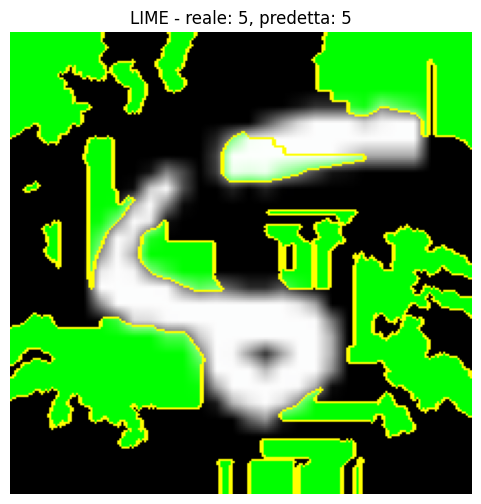

In [ ]:
# Cerca la prima immagine del test set che è un 5
for idx in range(len(testset)):
    image, label = testset[idx]
    if label == 5:
        break

print("Indice immagine:", idx)
print("Classe reale:", label)


# Conversione per LIME (CHW -> HWC)
image_np = image.permute(1, 2, 0).numpy()

# Define ImageNet mean and standard deviation for denormalization (if not already defined globally)
mean_imgnet = np.array([0.485, 0.456, 0.406]).reshape(1, 1, 3)
std_imgnet = np.array([0.229, 0.224, 0.225]).reshape(1, 1, 3)

# Calcolo della spiegazione LIME
explanation = explainer.explain_instance(
    image_np,
    batch_predict,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)


# Estrazione delle regioni importanti
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=False,
    num_features=50,
    hide_rest=False
)


# Predizione della DenseNet sulla stessa immagine
with torch.no_grad():

    input_img = torch.tensor(image_np)\
        .permute(2,0,1)\
        .unsqueeze(0)\
        .float()\
        .to(device)

    output = model(input_img)

    prob = torch.softmax(output, dim=1)


predicted = torch.argmax(prob, dim=1).item()


print("Classe reale:", label)
print("Classe predetta:", predicted)
print("Probabilità:", prob[0][predicted].item())


# Visualizzazione LIME
plt.figure(figsize=(6,6))

# Denormalize temp for display
denormalized_temp = temp * std_imgnet + mean_imgnet
denormalized_temp = np.clip(denormalized_temp, 0, 1) # Clip to [0, 1] range

plt.imshow(mark_boundaries(denormalized_temp, mask))

plt.title(
    f"LIME - reale: {label}, predetta: {predicted}"
)

plt.axis("off")
plt.show()


Nonostante la classificazione corretta, la spiegazione suggerisce che il modello attribuisce importanza anche a regioni non direttamente riconducibili alla cifra. Questo potrebbe indicare che il modello utilizza caratteristiche non ottimali e potrebbe beneficiare di un ulteriore fine-tuning o di tecniche di data augmentation.

# Analisi degli errori:
Per ciascuna cifra viene ricercato il primo esempio classificato erroneamente. Successivamente vengono generate le mappe di Integrated Gradients e Grad-CAM per comprendere quali regioni dell'immagine hanno influenzato la classificazione errata.

Le immagini visualizzate nelle sezioni di interpretazione sono state trattate con l’obiettivo di rendere leggibili le mappe di salienza senza alterare la struttura informativa principale. In questdo caso, la visualizzazione ha una funzione di supporto all’analisi più che di ricostruzione perfettamente fotometrica dell’immagine originale. La pipeline di denormalizzazione può essere migliorata, ma questo non inficia la validità complessiva delle osservazioni qualitative, bsate sulla localizzazione delle aree salienti e non sui valori "cromatici" assoluti.

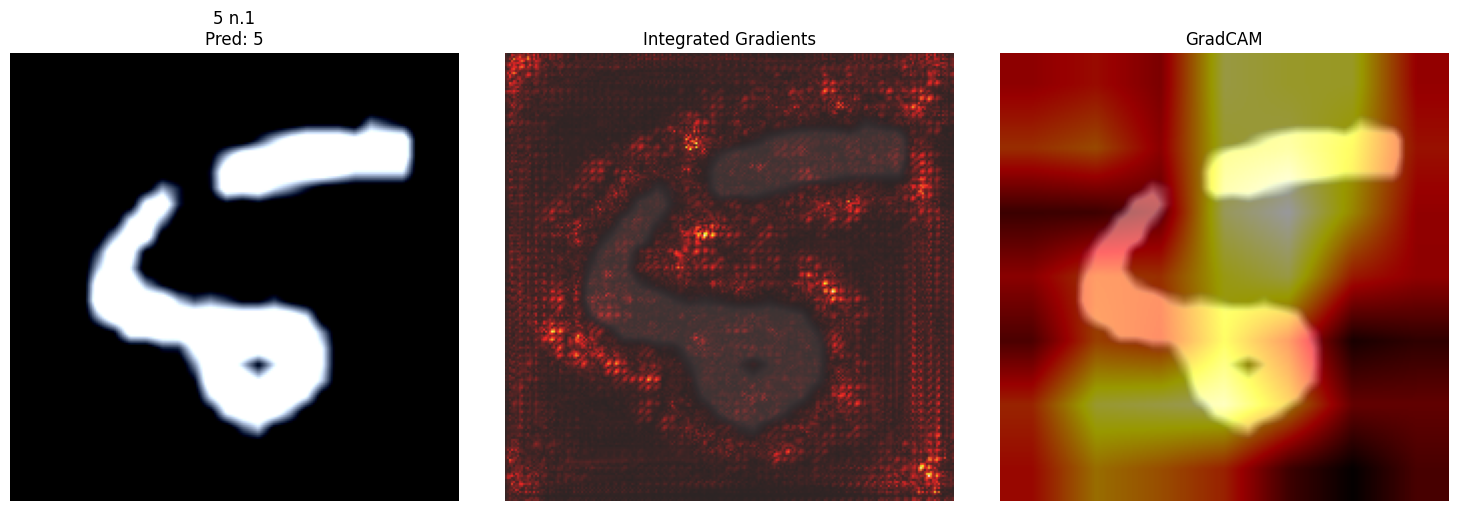

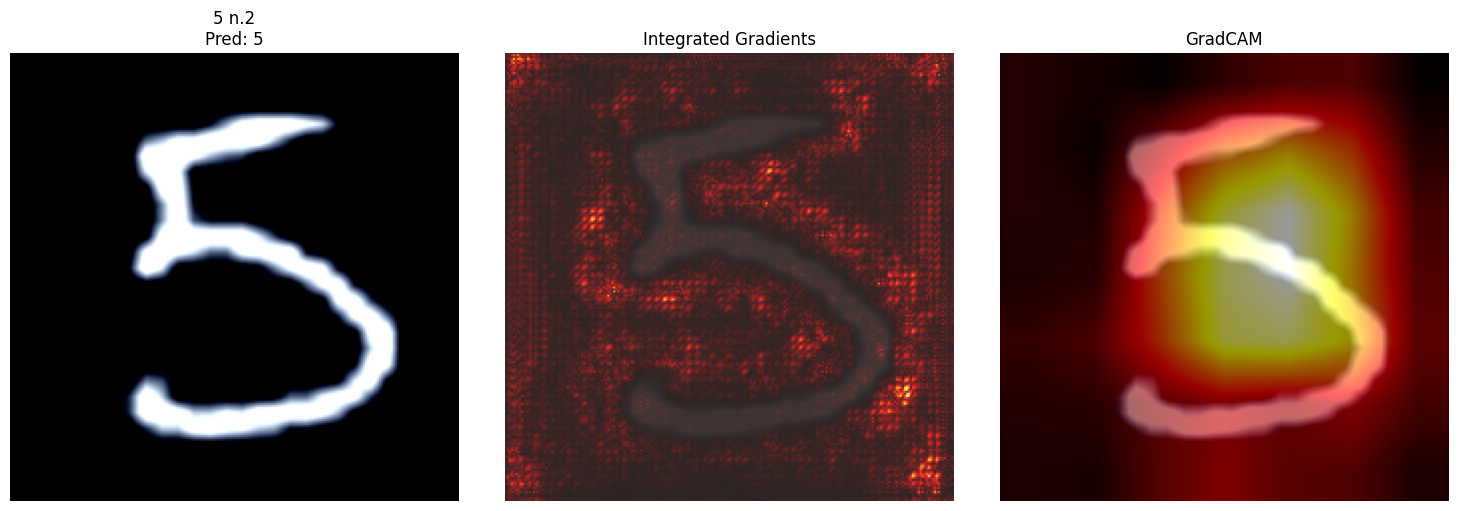

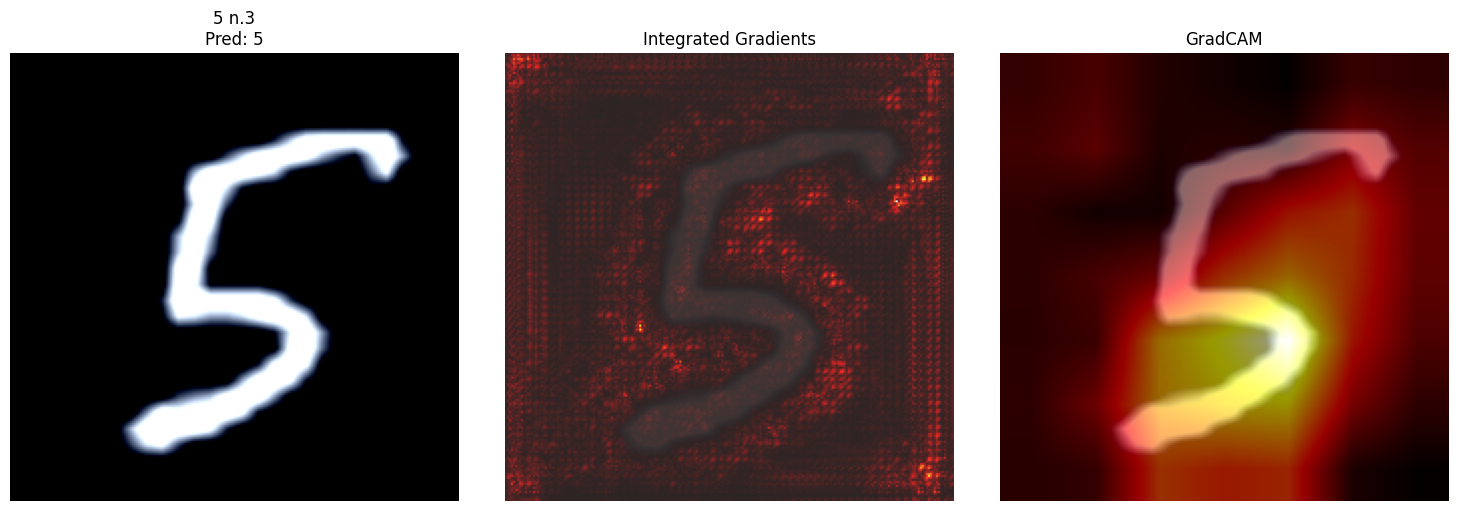

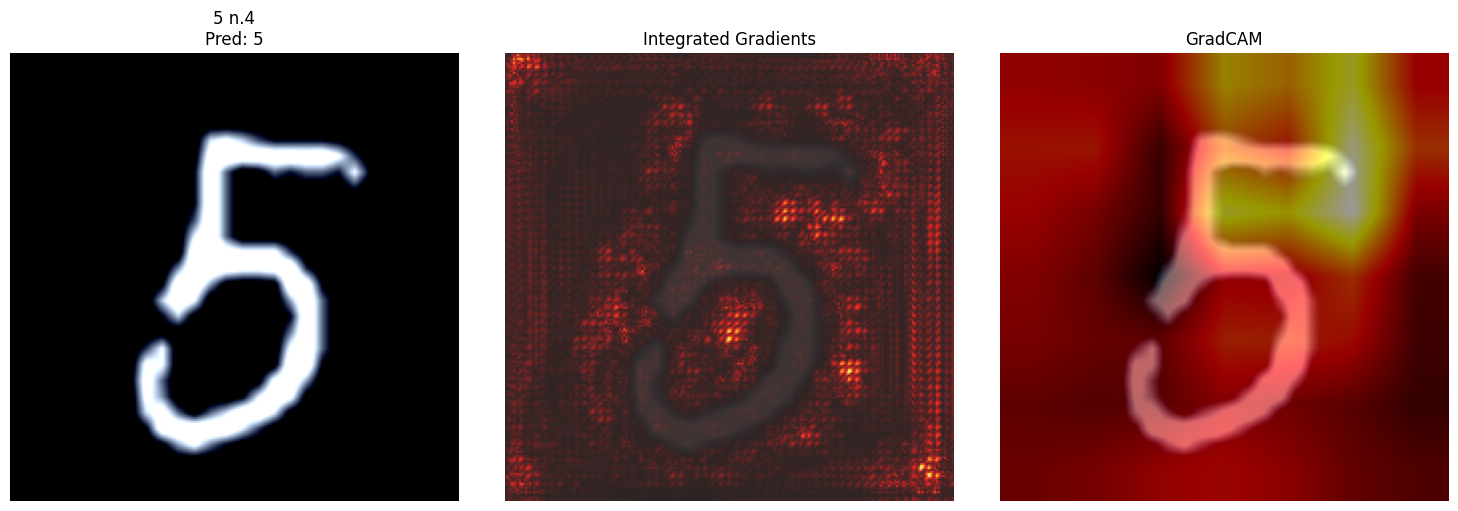

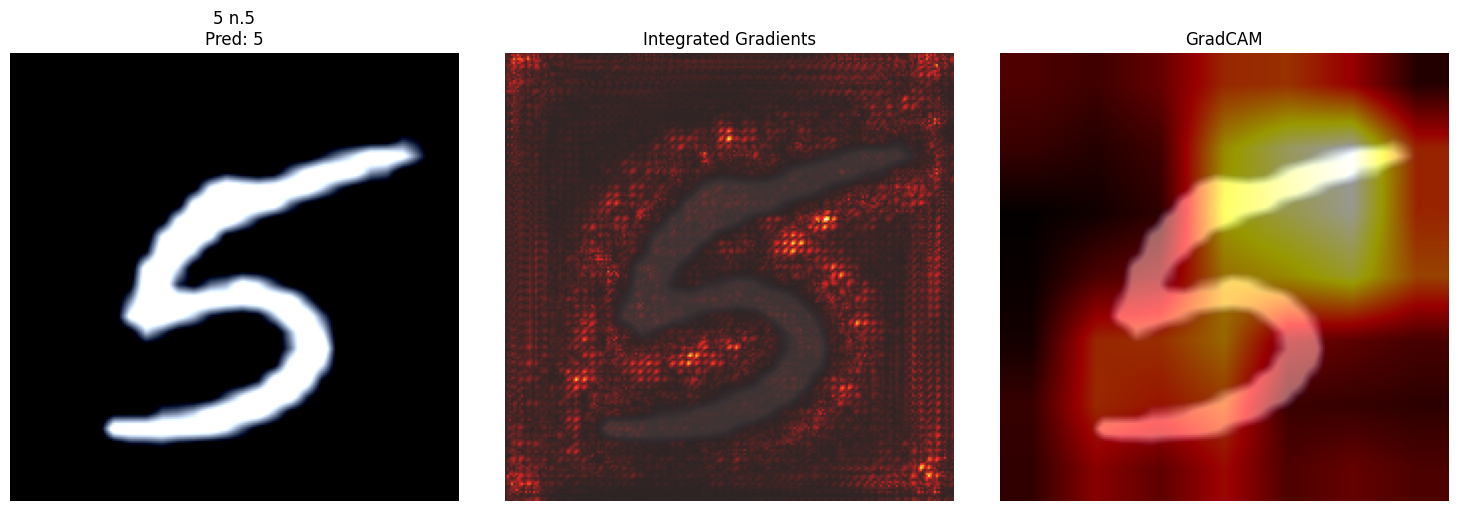

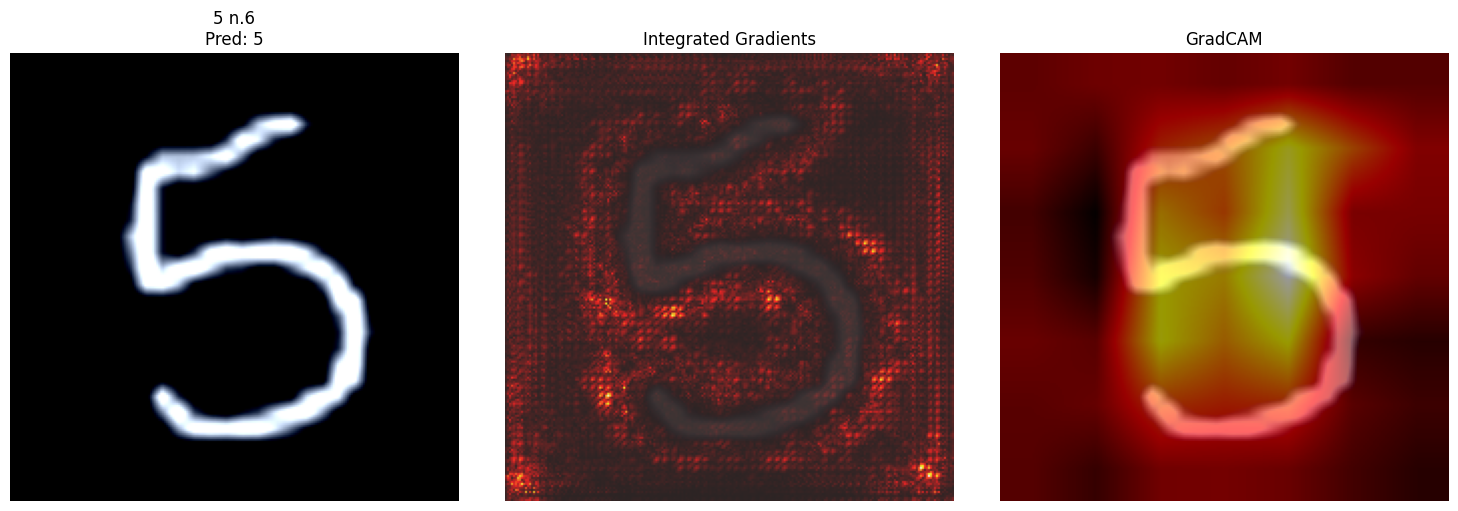

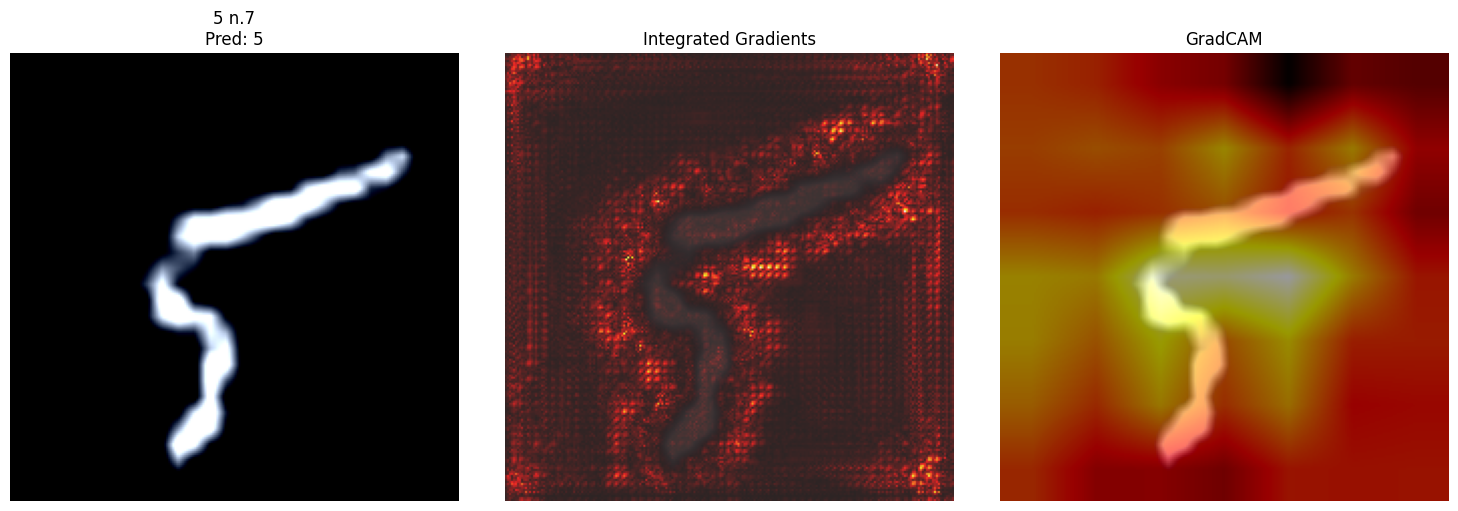

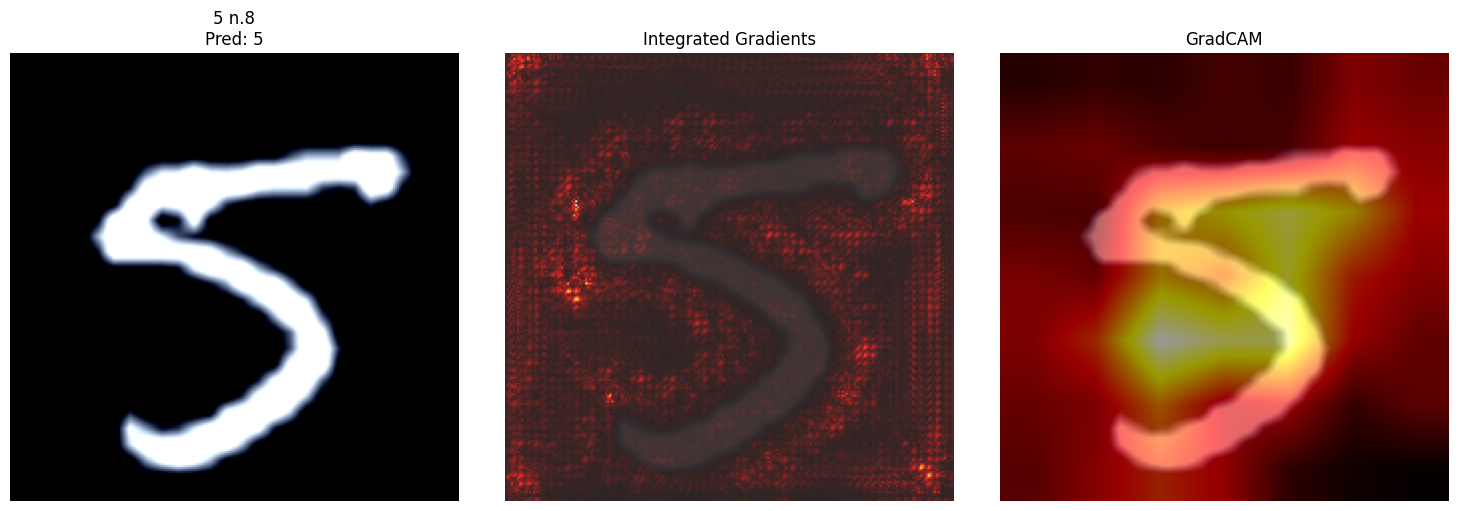

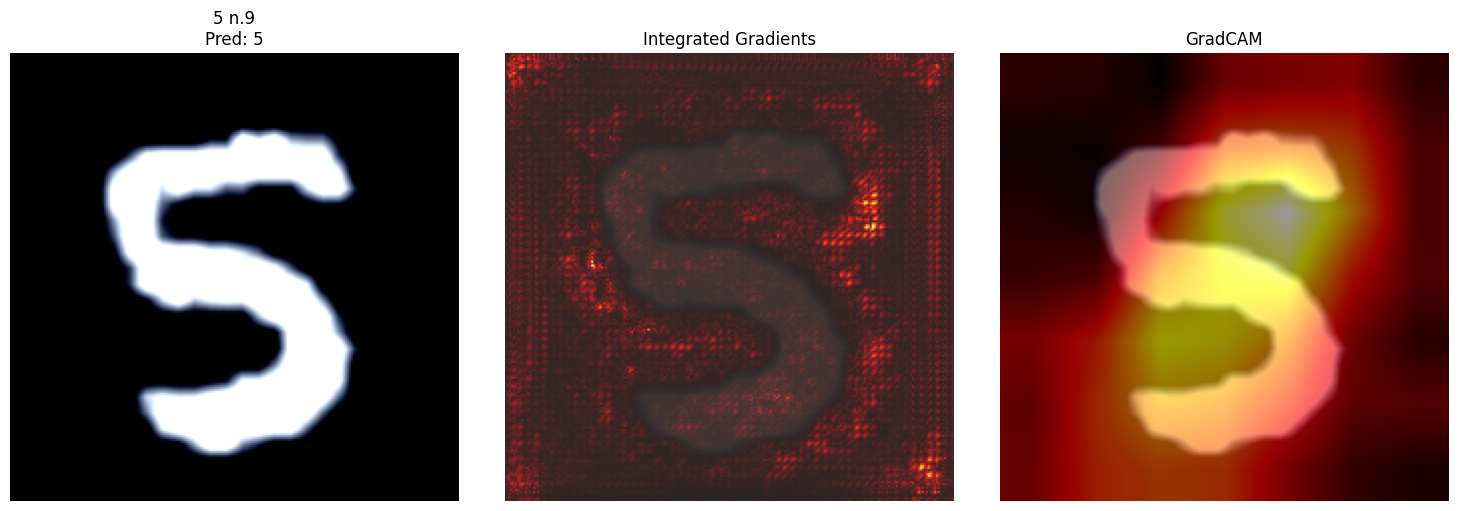

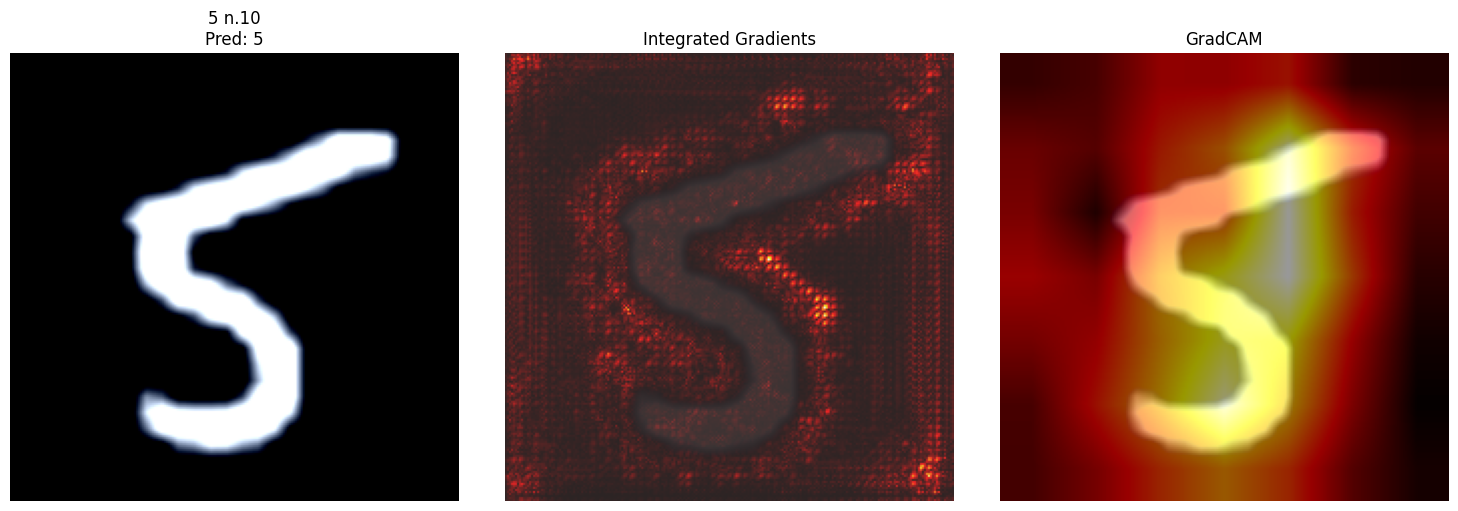

In [ ]:
ig = IntegratedGradients(model)
layer_gradcam = LayerGradCam(model, model.features.denseblock4.denselayer16.conv2)

model.eval()

contatore = 0

for image, label in testset:

    # Considera solo i 5
    if label != 5:
        continue

    input_img = image.unsqueeze(0).to(device)
    input_label = torch.tensor(label).to(device)

    with torch.no_grad():
        outputs = model(input_img)
        _, predicted = torch.max(outputs, 1)

    # Integrated Gradients
    ig_attr = ig.attribute(input_img,
                           target=input_label,
                           n_steps=50)

    # GradCAM
    gradcam_attr = layer_gradcam.attribute(input_img,
                                           target=input_label)

    plt.figure(figsize=(15,5))

    # Immagine originale
    plt.subplot(131)
    orig_img = input_img.squeeze().cpu().numpy()
    orig_img = np.transpose(orig_img, (1,2,0))

    plt.imshow(orig_img * 0.5 + 0.5)
    plt.title(f'5 n.{contatore+1}\nPred: {predicted.item()}')
    plt.axis("off")

    # Integrated Gradients
    plt.subplot(132)

    ig_map = ig_attr.abs().sum(dim=1).squeeze().cpu().numpy()
    ig_map = (ig_map - ig_map.min()) / (ig_map.max() - ig_map.min() + 1e-8)

    plt.imshow(orig_img * 0.5 + 0.5, alpha=0.3)
    plt.imshow(ig_map, cmap="hot", alpha=0.8)
    plt.title("Integrated Gradients")
    plt.axis("off")

    # GradCAM
    plt.subplot(133)

    gradcam_map = gradcam_attr.squeeze().cpu().detach().numpy()
    gradcam_map = (gradcam_map - gradcam_map.min()) / (gradcam_map.max() - gradcam_map.min() + 1e-8)

    gradcam_map = F.interpolate(
        torch.tensor(gradcam_map).unsqueeze(0).unsqueeze(0),
        size=(224,224),
        mode="bilinear",
        align_corners=False
    ).squeeze().numpy()

    plt.imshow(orig_img * 0.5 + 0.5)
    plt.imshow(gradcam_map, cmap="hot", alpha=0.6)
    plt.title("GradCAM")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    contatore += 1

    if contatore == 10:
        break


===== CIFRA 0 =====
Classe reale: 0
Classe predetta: 7
Probabilità: 0.397926390171051


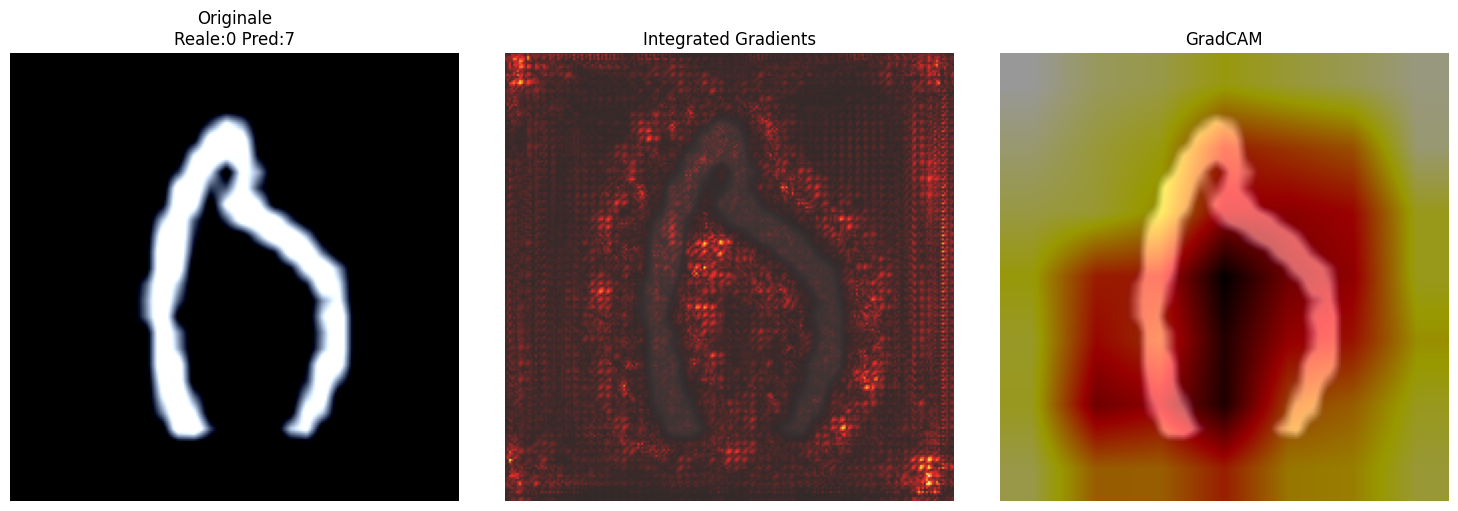


===== CIFRA 1 =====
Classe reale: 1
Classe predetta: 7
Probabilità: 0.4974239468574524


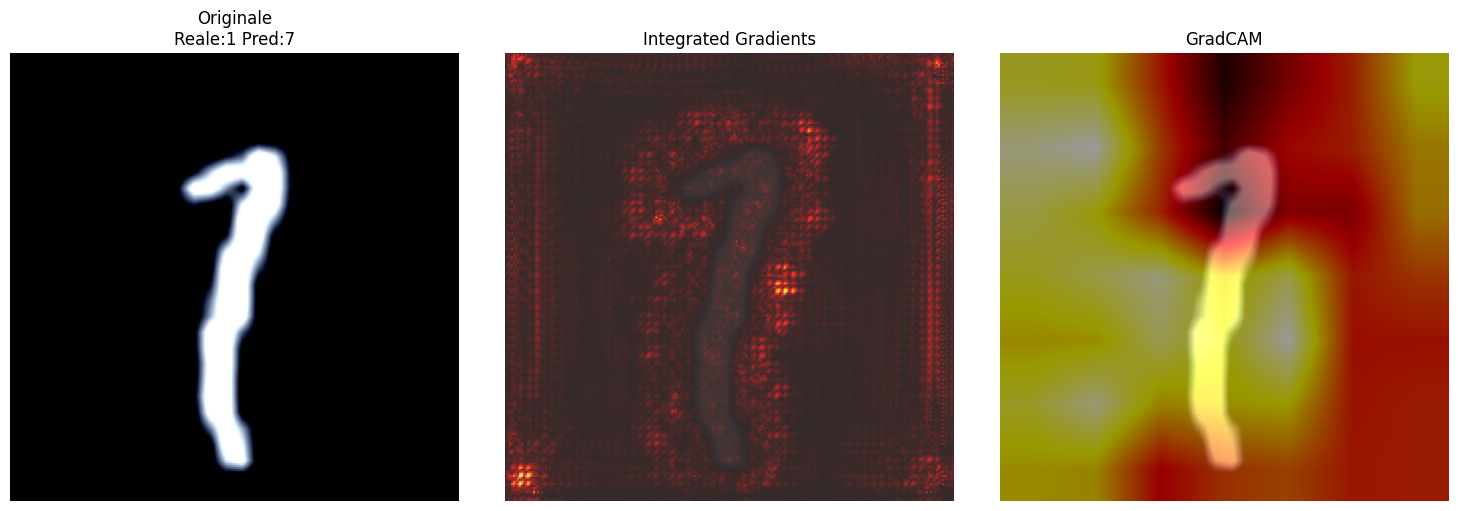


===== CIFRA 2 =====
Classe reale: 2
Classe predetta: 9
Probabilità: 0.6376509070396423


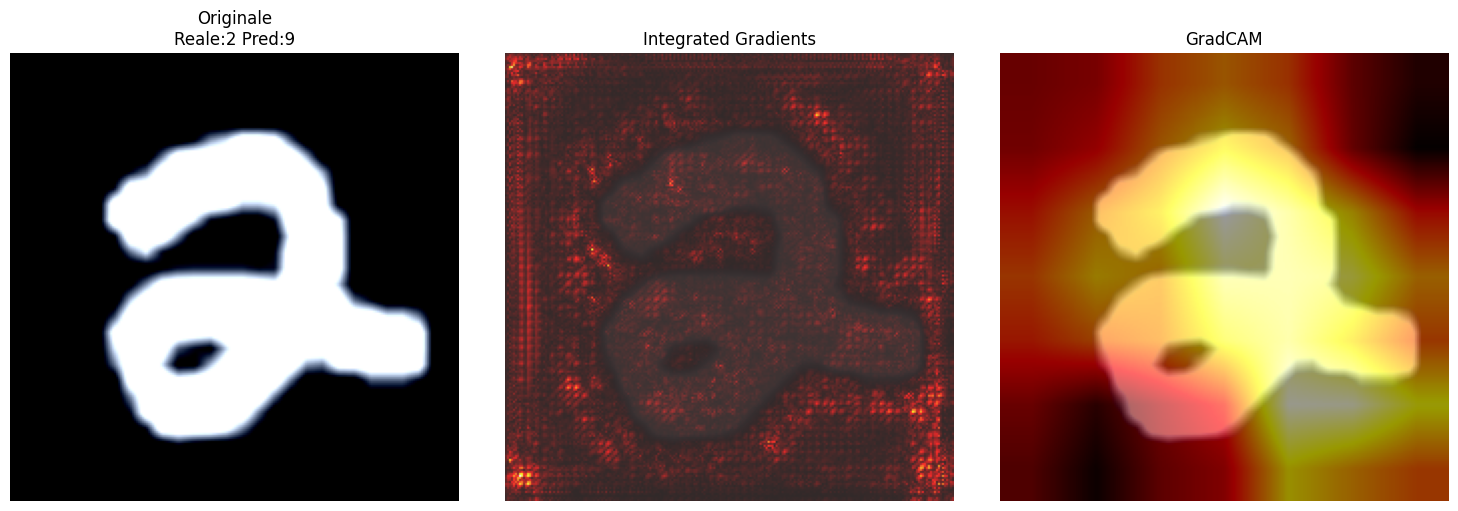


===== CIFRA 3 =====
Classe reale: 3
Classe predetta: 2
Probabilità: 0.38606107234954834


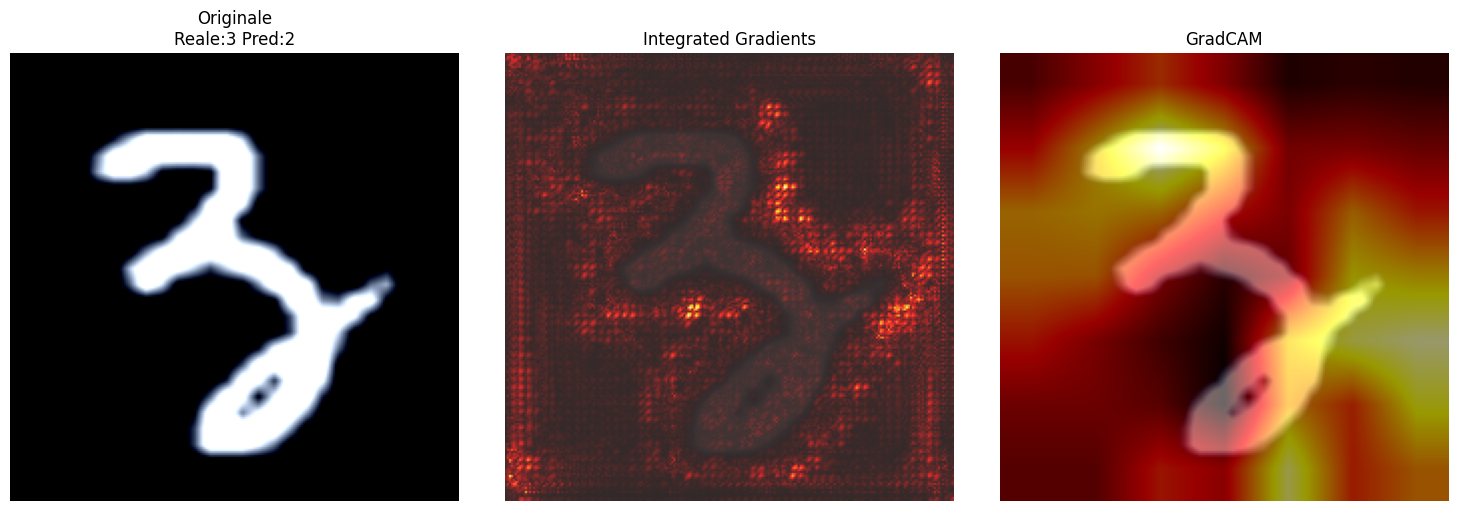


===== CIFRA 4 =====
Classe reale: 4
Classe predetta: 7
Probabilità: 0.6151768565177917


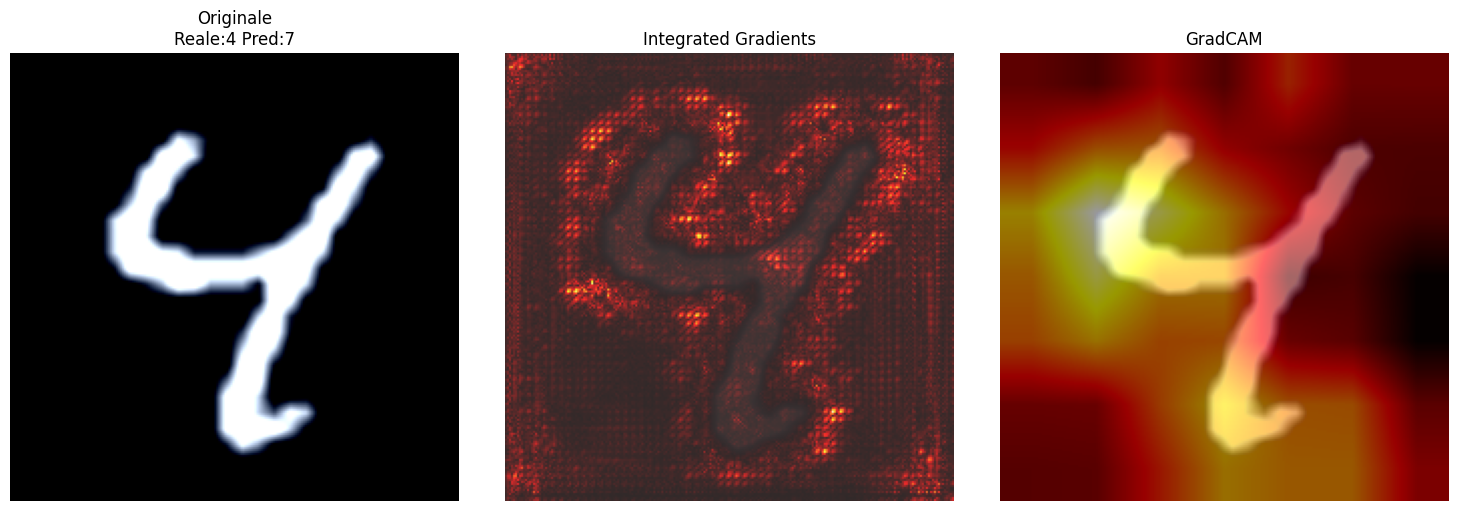


===== CIFRA 5 =====
Classe reale: 5
Classe predetta: 3
Probabilità: 0.7513701319694519


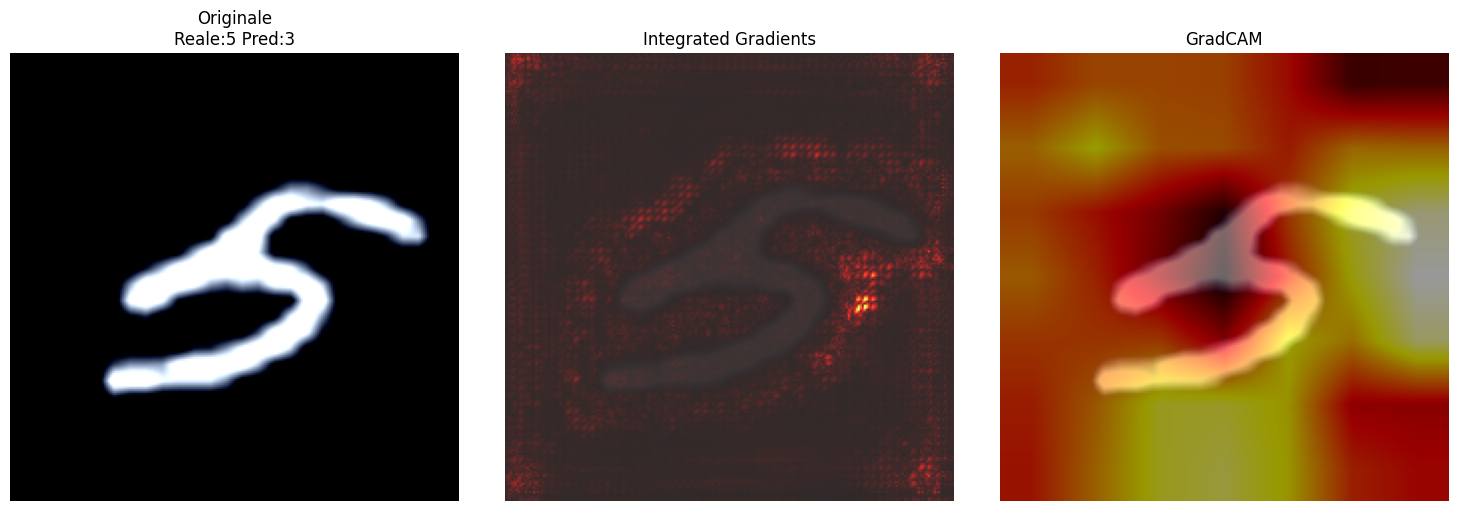


===== CIFRA 6 =====
Classe reale: 6
Classe predetta: 4
Probabilità: 0.30661627650260925


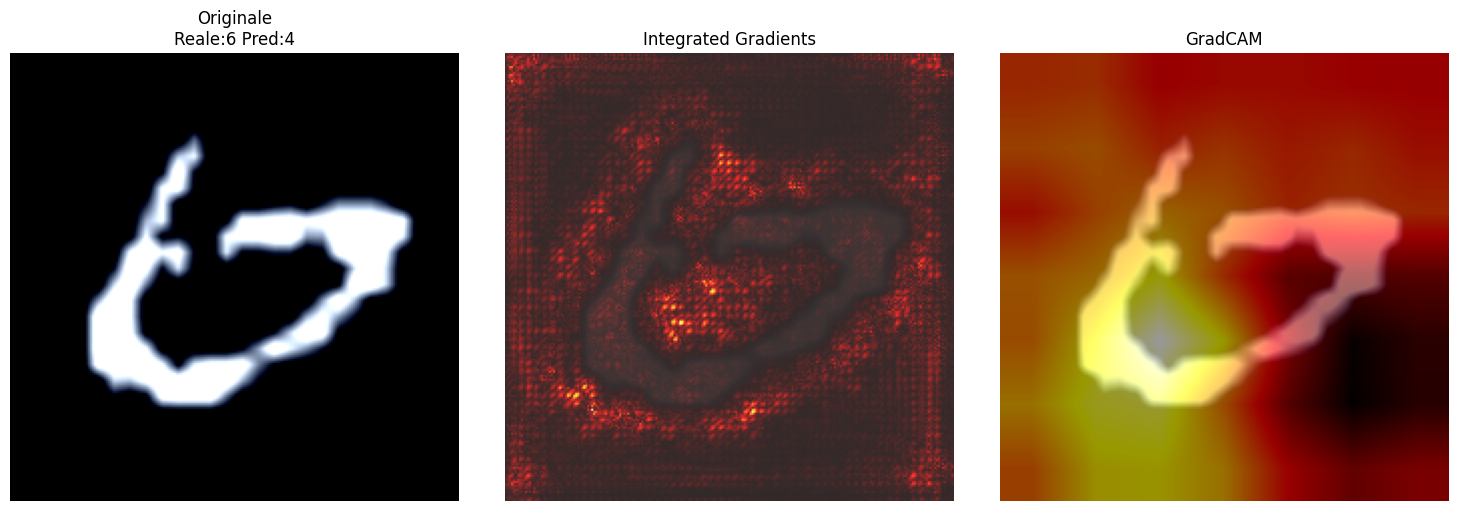


===== CIFRA 7 =====
Classe reale: 7
Classe predetta: 4
Probabilità: 0.406468003988266


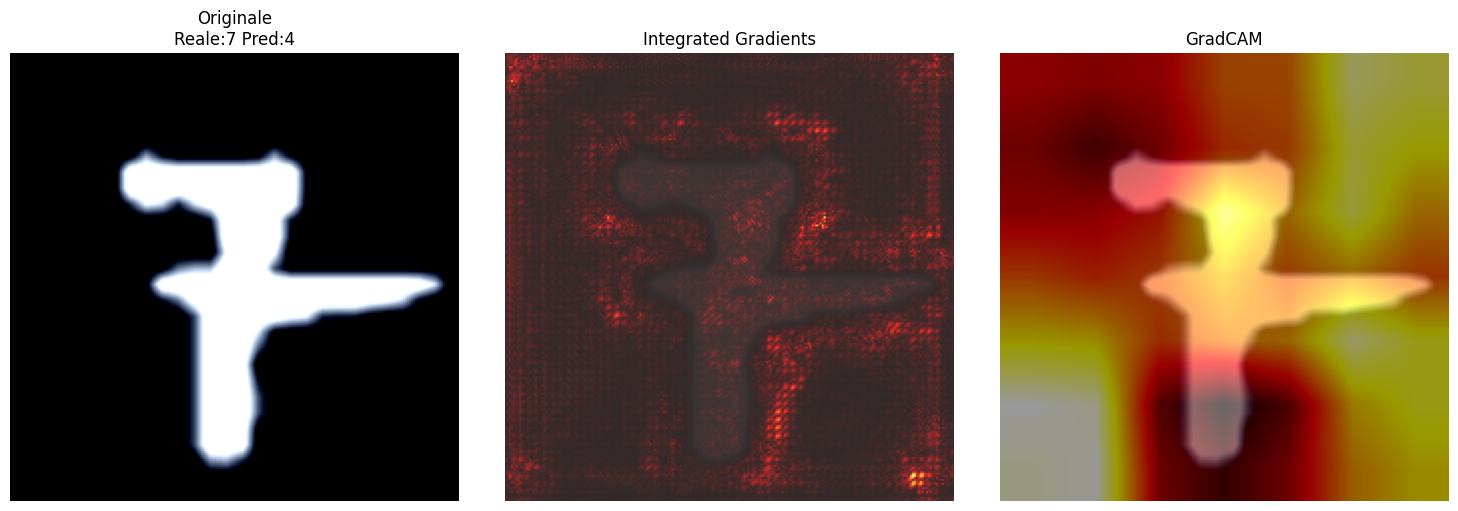


===== CIFRA 8 =====
Classe reale: 8
Classe predetta: 3
Probabilità: 0.5107276439666748


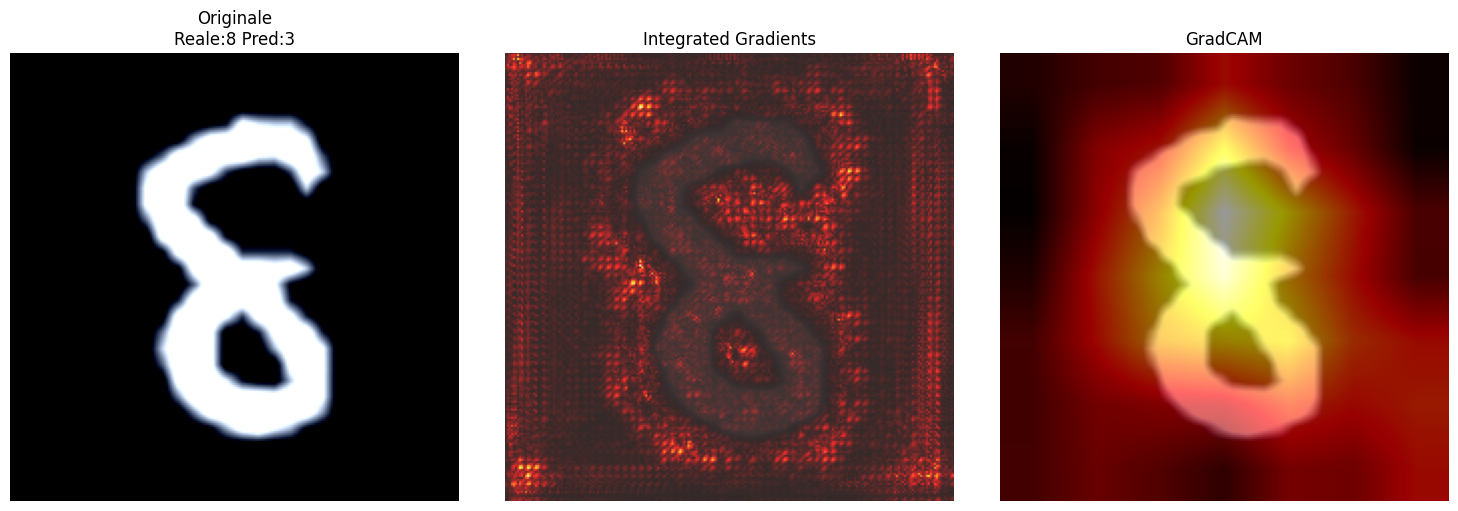


===== CIFRA 9 =====
Classe reale: 9
Classe predetta: 7
Probabilità: 0.695430338382721


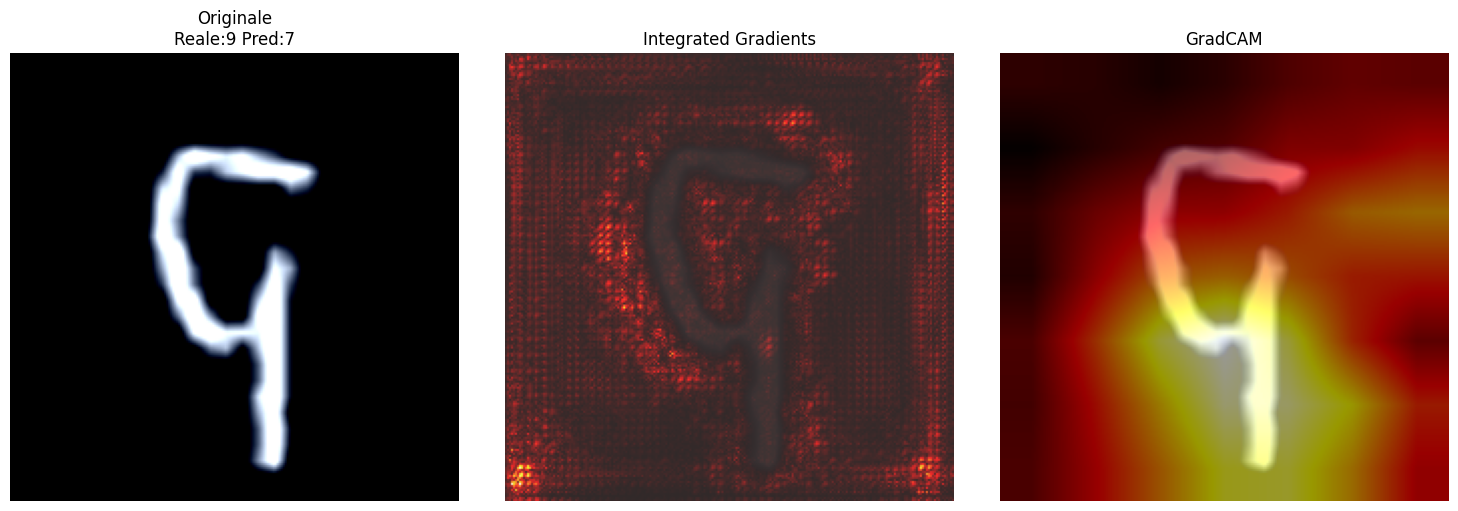

In [ ]:
ig = IntegratedGradients(model)
layer_gradcam = LayerGradCam(
    model,
    model.features.denseblock4.denselayer16.conv2
)

model.eval()

for digit in range(10):

    trovato = False

    for image, label in testset:

        if label != digit:
            continue

        input_img = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_img)
            prob = torch.softmax(output, dim=1)
            predicted = torch.argmax(prob, dim=1).item()

        # Cerchiamo solo errori
        if predicted == label:
            continue

        trovato = True

        print(f"\n===== CIFRA {digit} =====")
        print("Classe reale:", label)
        print("Classe predetta:", predicted)
        print("Probabilità:", prob[0][predicted].item())

        # Integrated Gradients
        ig_attr = ig.attribute(
            input_img,
            target=label,
            n_steps=50
        )

        # GradCAM
        gradcam_attr = layer_gradcam.attribute(
            input_img,
            target=label
        )

        plt.figure(figsize=(15,5))

        # Immagine originale
        plt.subplot(131)

        orig_img = input_img.squeeze().cpu().numpy()
        orig_img = np.transpose(orig_img,(1,2,0))

        plt.imshow(orig_img*0.5+0.5)
        plt.title(f"Originale\nReale:{label} Pred:{predicted}")
        plt.axis("off")

        # Integrated Gradients
        plt.subplot(132)

        ig_map = ig_attr.abs().sum(dim=1).squeeze().cpu().numpy()
        ig_map = (ig_map-ig_map.min())/(ig_map.max()-ig_map.min()+1e-8)

        plt.imshow(orig_img*0.5+0.5,alpha=0.2)
        plt.imshow(ig_map,cmap="hot",alpha=0.8)
        plt.title("Integrated Gradients")
        plt.axis("off")

        # GradCAM
        plt.subplot(133)

        gradcam_map = gradcam_attr.squeeze().cpu().detach().numpy()
        gradcam_map = (gradcam_map-gradcam_map.min())/(gradcam_map.max()-gradcam_map.min()+1e-8)

        gradcam_map = F.interpolate(
            torch.tensor(gradcam_map).unsqueeze(0).unsqueeze(0),
            size=(224,224),
            mode="bilinear",
            align_corners=False
        ).squeeze().numpy()

        plt.imshow(orig_img*0.5+0.5)
        plt.imshow(gradcam_map,cmap="hot",alpha=0.6)
        plt.title("GradCAM")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

        # passa alla cifra successiva
        break

    if not trovato:
        print(f"Nessun errore trovato per la cifra {digit}.")

# Report Finale

## Analisi delle Mappe di Salienza:
Sono state implementate tre tecniche di Explainable AI: LIME, Integrated Gradients e Grad-CAM.

LIME ha evidenziato le regioni dell'immagine maggiormente responsabili della classificazione mediante perturbazioni locali.

Integrated Gradients ha permesso di attribuire a ciascun pixel un contributo rispetto alla decisione finale.

Grad-CAM ha evidenziato le regioni dell'immagine maggiormente responsabili dell'attivazione degli ultimi layer convoluzionali del modello.

## Errori
L'analisi delle classificazioni errate mostra che il modello, in alcuni casi, concentra l'attenzione su regioni poco rappresentative della cifra oppure trascura tratti significativi. Questo suggerisce che ulteriori operazioni di fine-tuning o tecniche di data augmentation potrebbero migliorare la robustezza del classificatore.

## Conclusioni
Le tecniche di Explainable AI implementate hanno consentito di interpretare il comportamento della DenseNet121, rendendo maggiormente trasparenti le decisioni del modello. Le mappe di salienza hanno evidenziato sia i punti di forza sia alcune criticità del classificatore, dimostrando come tali strumenti possano supportare il miglioramento delle prestazioni e aumentare la fiducia nelle decisioni automatiche.

## Sistema Spiegabile (Opzionale)
Un possibile sistema completamente spiegabile potrebbe essere basato su un classificatore a regole o su un albero decisionale costruito a partire da caratteristiche geometriche delle cifre (numero di segmenti, presenza di curve, estremi, area occupata). Sebbene meno accurato di una rete neurale profonda, un approccio di questo tipo fornirebbe una spiegazione esplicita di ogni decisione presa.